<a href="https://colab.research.google.com/github/aman-raj-2011/CODSOFT-INTERNSHIP/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost imbalanced-learn torch streamlit pyngrok joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 77.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv('/content/TransactionsDataset.csv')

print(df.shape)
df.head()

(116851, 19)


,transaction_id,first_name,last_name,gender,dob,account_number,amount,city,country,category,purchase_reason,latitude,longitude,transaction_hour,relation,payment_type,user_type,distance_km,fraud
0,71769.0,Crystal,Curry,F,1963-02-20,3.595420e+15,4647.00,Phillipsmouth,Saint Helena,entertainment,business,66.227910,57.844577,9.0,family,card,old,12965.37,0.0
1,61165.0,Marissa,Massey,M,1970-03-14,3.758639e+14,4320.68,Lake Feliciashire,French Southern Territories,grocery,gift,-26.234253,-101.835805,23.0,suspicious,netbanking,new,16063.88,0.0
2,21899.0,Robyn,Curtis,M,1974-01-21,4.165350e+12,4519.41,Caseymouth,Georgia,shopping,personal use,-32.989041,80.789415,2.0,unknown,wallet,old,19417.90,0.0
3,29683.0,Ronald,Wolfe,F,1965-05-05,3.573175e+15,2480.48,West Angelachester,Mauritius,travel,business,30.968503,17.101686,11.0,suspicious,rtgs,new,7280.59,0.0
4,118280.0,David,Ramirez,F,2006-05-14,6.544689e+15,2102.81,Burkemouth,Cape Verde,shopping,luxury,0.501417,-44.636880,5.0,merchant,wallet,new,1658.08,0.0


In [ ]:
print("\nNull Values")
print(df.isnull().sum())

df = df.dropna()

print("\nDuplicate Rows")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("Clean Dataset Shape:", df.shape)


Null Values
transaction_id      2326
first_name          2325
last_name           2353
gender              2336
dob                 2343
account_number      2350
amount              2328
city                2336
country             2338
category            2320
purchase_reason     2343
latitude            2343
longitude           2343
transaction_hour    2343
relation            2350
payment_type        2354
user_type           2343
distance_km         2335
fraud               2338
dtype: int64

Duplicate Rows
3755
Clean Dataset Shape: (75676, 19)


In [ ]:
df['age'] = 2025 - pd.to_datetime(df['dob']).dt.year

# Night transaction
df['is_night'] = df['transaction_hour'].apply(lambda x: 1 if x >= 23 or x <= 4 else 0)

# High amount flag
df['high_amount'] = (df['amount'] > 3000).astype(int)

# Suspicious relation
df['is_suspicious_relation'] = df['relation'].isin(['unknown', 'suspicious']).astype(int)

# New user flag
df['is_new_user'] = (df['user_type'] == 'new').astype(int)

# Long distance flag
df['long_distance'] = (df['distance_km'] > 5000).astype(int)

In [ ]:
cols_to_drop = [
    'transaction_id','account_number',
    'first_name','last_name',
    'latitude','longitude','dob'
]

df = df.drop(columns=cols_to_drop, errors='ignore')
print("After preprocessing:", df.shape)

After preprocessing: (75676, 18)


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

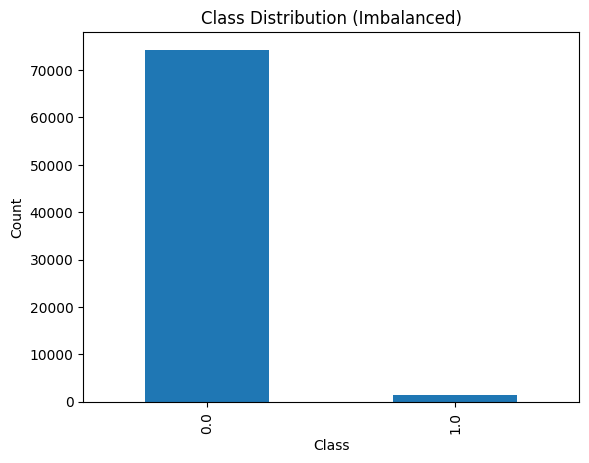

Class Ratio:
 fraud
0.0    0.98183
1.0    0.01817
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['fraud'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Imbalanced)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print("Class Ratio:\n", df['fraud'].value_counts(normalize=True))

In [ ]:
X = df.drop('fraud', axis=1)
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_res).value_counts())

Before SMOTE: fraud
0.0    59440
1.0     1100
Name: count, dtype: int64
After SMOTE: fraud
0.0    59440
1.0    59440
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, roc_curve, classification_report

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

# ================= MODELS =================
models = {
    "Logistic": LogisticRegression(max_iter=400),

    "Decision Tree": DecisionTreeClassifier(max_depth=6),

    "Random Forest": RandomForestClassifier(
      n_estimators=100,
      max_depth=8,
      class_weight="balanced"
      ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        gamma=1,
        min_child_weight=5,
        eval_metric='logloss',
        random_state=42
    )
}

# ================= RESULTS STORAGE =================
results = {
    "Model": [],
    "Recall": [],
    "Precision": [],
    "F1 Score": [],
    "ROC-AUC": []
}

best_model = None

# For ROC curve plotting
roc_data = {}

# ================= TRAINING LOOP =================
for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train_res, y_train_res)

    y_prob = model.predict_proba(X_test)[:,1]

    # threshold tuning
    y_pred = (y_prob > 0.2).astype(int)

    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print("Recall:", rec)
    print("Precision:", prec)
    print("F1 Score:", f1)
    print("ROC-AUC:", auc)

    results["Model"].append(name)
    results["Recall"].append(rec)
    results["Precision"].append(prec)
    results["F1 Score"].append(f1)
    results["ROC-AUC"].append(auc)

    # store ROC curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr)

    if name == "XGBoost":
        best_model = model


Training Logistic...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Recall: 0.6545454545454545
Precision: 0.018755861206627072
F1 Score: 0.03646677471636953
ROC-AUC: 0.5237949238702889

Training Decision Tree...
Recall: 0.610909090909091
Precision: 0.019041142468548114
F1 Score: 0.036931193668938225
ROC-AUC: 0.5285441454447578

Training Random Forest...
Recall: 0.6618181818181819
Precision: 0.019355524832500266
F1 Score: 0.03761107666873321
ROC-AUC: 0.5038749380624086

Training XGBoost...
Recall: 0.8909090909090909
Precision: 0.01837959489872468
F1 Score: 0.03601617052554208
ROC-AUC: 0.5305808369680249


In [ ]:
results_df = pd.DataFrame(results)

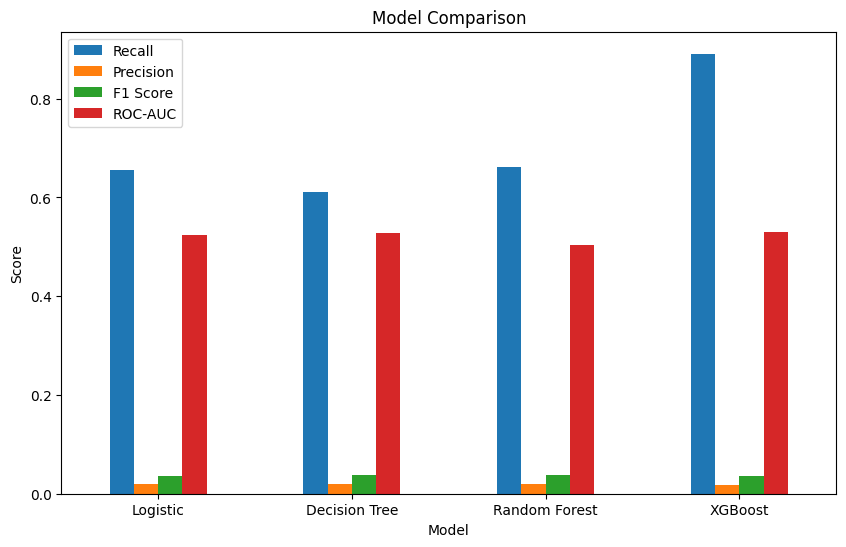

In [ ]:
results_df.set_index("Model").plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

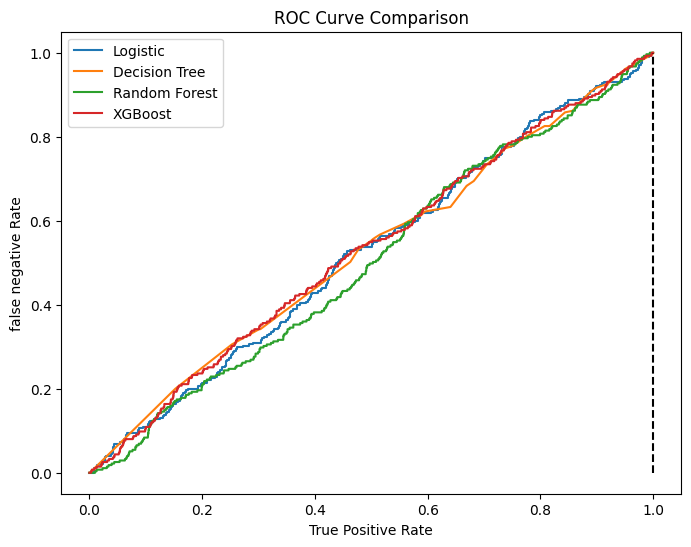

In [ ]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([1,1],[0,1],'k--')  # diagonal
plt.xlabel("True Positive Rate")
plt.ylabel("false negative Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

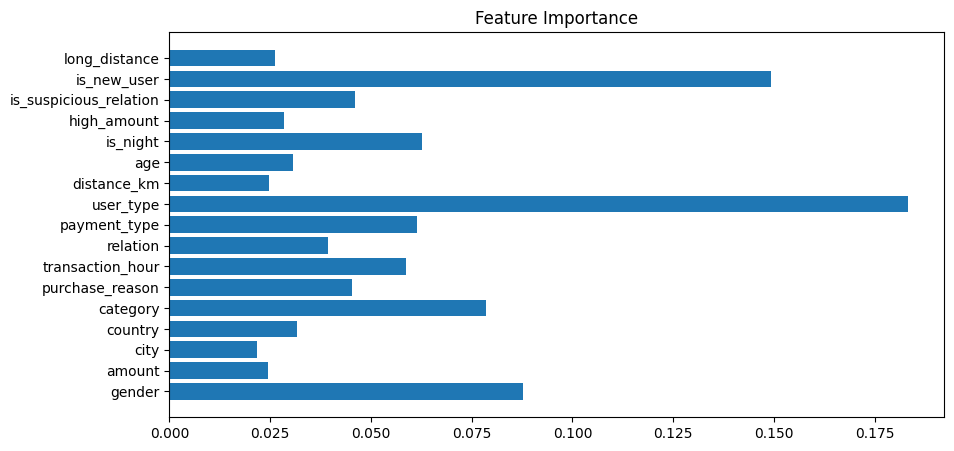

In [ ]:
import matplotlib.pyplot as plt

importance = best_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "model.pkl")
joblib.dump(X_train.columns, "columns.pkl")
model = best_model

In [ ]:
%%writefile app.py

# =========================
# IMPORTS
# =========================
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import pickle

# =========================
# PAGE CONFIG (WHITE UI)
# =========================
st.set_page_config(page_title="Fraud Detection", layout="centered")

# Custom CSS for clean white UI
st.markdown("""
<style>
body {
    background-color: white;
}
.big-text {
    font-size: 32px !important;
    font-weight: bold;
    text-align: center;
}
.footer {
    bottom: 10px;
    width: 100%;
    text-align: center;
    font-size: 16px;
    color: white;
}
</style>
""", unsafe_allow_html=True)

# =========================
# FOOTER FUNCTION
# =========================
def footer():
    st.markdown("""
    <div class="footer">
    DIT University , Dehradun | Final-Year Capstone Project ( BTIT-08 ) <br>
    Saksham Patwal | Subham Singh | Aman Raj <br>
    1000018319 | 1000017792 | 1000017798
    </div>
    """, unsafe_allow_html=True)

# =========================
# LOGIN SYSTEM
# =========================
if "logged_in" not in st.session_state:
    st.session_state.logged_in = False

if not st.session_state.logged_in:

    st.title("🔐 Login")

    username = st.text_input("Username")
    password = st.text_input("Password", type="password")

    if st.button("Login"):
        if username == "btit08" and password == "1234":
            st.session_state.logged_in = True
            st.success("Login Successful. Click login again")
        else:
            st.error("Invalid Credentials")

    footer()
    st.stop()

# =========================
# LOAD MODEL
# =========================
model = pickle.load(open("model.pkl", "rb"))
columns = joblib.load("columns.pkl")

# =========================
# MAIN UI
# =========================
st.title("💳 Fraud Transaction Detection System")

st.write("Fill details to check if transaction is fraud")

# =========================
# INPUTS WITH TOOLTIPS (?)
# =========================
amount = st.number_input(
    "Transaction Amount (?)",
    min_value=1.0,
    help="Enter the transaction amount. High amounts may indicate fraud."
)

age = st.number_input(
    "Age (?)",
    min_value=18,
    max_value=100,
    help="Age of the user making the transaction."
)

hour = st.slider(
    "Transaction Hour (?)",
    0, 23,
    help="Time of transaction (0–23). Late night transactions are risky."
)

relation = st.selectbox(
    "Relation (?)",
    ['self','family','friend','merchant','unknown','suspicious'],
    help="Relationship between sender and receiver."
)

payment_type = st.selectbox(
    "Payment Type (?)",
    ['netbanking','rtgs','card','upi','wallet'],
    help="Mode of payment used."
)

user_type = st.selectbox(
    "User Type (?)",
    ['old','new'],
    help="Whether the user is new or existing."
)

distance = st.number_input(
    "Distance (km) (?)",
    min_value=0.0,
    help="Distance between transaction locations. Long distance may be suspicious."
)

# =========================
# PREDICTION
# =========================
if st.button("Predict"):

    # Feature Engineering
    is_night = 1 if (hour >= 23 or hour <= 4) else 0
    high_amount = 1 if amount > 3000 else 0
    is_suspicious_relation = 1 if relation in ['unknown','suspicious'] else 0
    is_new_user = 1 if user_type == 'new' else 0
    long_distance = 1 if distance > 5000 else 0

    # Encoding
    relation_map = {'self':0,'family':1,'friend':2,'merchant':3,'unknown':4,'suspicious':5}
    payment_map = {'netbanking':0,'rtgs':1,'card':2,'upi':3,'wallet':4}
    user_map = {'old':0,'new':1}

    input_df = pd.DataFrame(columns=columns)
    input_df.loc[0] = 0

    input_df['amount'] = amount
    input_df['age'] = age
    input_df['transaction_hour'] = hour
    input_df['distance_km'] = distance

    input_df['is_night'] = is_night
    input_df['high_amount'] = high_amount
    input_df['is_suspicious_relation'] = is_suspicious_relation
    input_df['is_new_user'] = is_new_user
    input_df['long_distance'] = long_distance

    input_df['relation'] = relation_map[relation]
    input_df['payment_type'] = payment_map[payment_type]
    input_df['user_type'] = user_map[user_type]

    input_df = input_df.fillna(0)

    prob = model.predict_proba(input_df)[0][1]

    threshold = 0.2

    if prob < threshold:
        result_text = "🚨 Fraudulent Transaction"
        st.markdown(f'<p class="big-text" style="color:red;">{result_text}</p>', unsafe_allow_html=True)
    else:
        result_text = "✅ Legit Transaction"
        st.markdown(f'<p class="big-text" style="color:green;">{result_text}</p>', unsafe_allow_html=True)

    st.write(f"Fraud Probability: {(100 - round(prob*100,2))}%")

    # =========================
    # EXPLANATION
    # =========================
    reasons = []

    if is_night:
        reasons.append("Late night transaction")
    if is_new_user:
        reasons.append("New user")
    if high_amount:
        reasons.append("High amount")
    if is_suspicious_relation:
        reasons.append("Suspicious relation")
    if long_distance:
        reasons.append("Long distance")

    if reasons:
        st.warning("Reasons: " + ", ".join(reasons))
    else:
        st.success("No strong fraud indicators")

# =========================
# FOOTER
# =========================
footer()

Writing app.py


In [ ]:
!pkill -f streamlit
!pkill -f ngrok

!pip install pyngrok --upgrade

from pyngrok import ngrok
ngrok.set_auth_token("32OIzXWdRpHfPhXZWWpP4UPSYBw_7enQUgvMy5xc7o9mUdEYG")

import os
os.system('streamlit run app.py &')

import time
time.sleep(8)

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://7553-34-106-221-168.ngrok-free.app" -> "http://localhost:8501"
